# Weak-lensing galaxy shape catalogue validation

## Global metacalibration

Contents.
- Metacalibration (global)
- Additive bias, ellipticity, magnitude distributions

> **_NOTE:_** Before running this notebook, set kernel to `main_set.ipynb'

In [42]:
%matplotlib inline

import os
from uncertainties import ufloat

In [43]:
from sp_validation.survey import *
from sp_validation.basic import *
from sp_validation.util import *
from sp_validation.basic import *
from sp_validation.plots import *
from sp_validation.plot_style import *
from sp_validation.calibration import *

## metacalibration for galaxies


The selection criteria for galaxies are
- Flags = 0 to select valid objects
- $\frac{T_{\rm gal}}{T_{\rm psf}}$ > 0.5  to select objects that are not too small compared to the PSF, thus not likely to be point-like
- SNR > 10 to cut noisy objects
- SNR < 500 to cut too bright objects, potentially too large for the postage stamp

### ngmix

In [63]:
gal_metacal = {}

for sh in shapes:
    gal_metacal[sh] = metacal(
        dd,
        m_gal[sh],
        prefix=sh.upper(),
        snr_min=gal_snr_min,
        snr_max=gal_snr_max,
        rel_size_min=gal_rel_size_min,
        verbose=verbose
    )

Metacal cuts: 10<snr<500, rel_size_min=0.5
Extracting 1m
Extracting 1p
Extracting 2m
Extracting 2p
Extracting noshear


#### Extract quantities after calibration and cuts (in metacal)

In [46]:
g_corr = {}
g_uncorr = {}
w = {}
mask = {}
ra = {}
dec = {}
ra_mean = {}
dec_mean = {}
mag = {}
snr = {}

for sh in shapes:
    g_corr[sh], g_uncorr[sh], w[sh], mask[sh] = (
        get_calibrated_quantities(gal_metacal[sh])
    )

    # coordinates
    ra[sh] = dd['XWIN_WORLD'][m_gal[sh]][mask[sh]]
    dec[sh] = dd['YWIN_WORLD'][m_gal[sh]][mask[sh]]
    ra_mean[sh] = np.mean(ra[sh])
    dec_mean[sh] = np.mean(dec[sh])

    # magnitude, from SExtractor
    mag[sh] = dd['MAG_AUTO'][m_gal[sh]][mask[sh]]

if 'ngmix' in shapes:
    # signal-to-noise ratio, only for ngmix, from fitted flux and error
    snr[sh] = (
        dd['NGMIX_FLUX_NOSHEAR'][m_gal['ngmix']][mask['ngmix']] 
        / dd['NGMIX_FLUX_ERR_NOSHEAR'][m_gal['ngmix']][mask['ngmix']]
    )

#### Compute coordinates for projection and spatial binning (needed later)

In [47]:
x = {}
y = {}

for sh in shapes:
    # Projection all objects from spherical to Cartesian coordinates
    x[sh], y[sh] =  radec2xy(ra_mean[sh], dec_mean[sh], ra[sh], dec[sh])

#### Compute field size

In [50]:
min_x = {}
max_x = {}
min_y = {}
max_y = {}
size_x_deg = {}
size_y_deg = {}

for sh in shapes:
    # Define mix, max and size
    min_x[sh] = np.min(x[sh])
    max_x[sh] = np.max(x[sh])
    min_y[sh] = np.min(y[sh])
    max_y[sh] = np.max(y[sh])

    size_x_deg[sh] = np.rad2deg(max_x[sh] - min_x[sh])
    size_y_deg[sh] = np.rad2deg(max_y[sh] - min_y[sh])

    print(
        f'{sh}: Field size in projected coordinates is (x, y) '
        + f'= ({size_x_deg[sh]:.2f}, {size_y_deg[sh]:.2f}) deg'
    )

ngmix: Field size in projected coordinates is (x, y) = (8.61, 7.20) deg


In [65]:
# Get coordinates for all objects
ra['all'] = dd['XWIN_WORLD']
dec['all'] = dd['YWIN_WORLD']

shapes_all = []
for sh in shapes:
    shapes_all.append(sh)
shapes_all.append('all')

In [54]:
# Number density
n_gal = {}
n_gal_sm = {}

for sh in shapes:
    n_gal[sh] = len(w[sh])
    n_gal_sm[sh] = len(np.where(m_gal[sh])[0])

    print_stats(sh, stats_file, verbose=verbose)
    print_stats(
        f'Number of galaxies after metacal = {n_gal[sh]}/{n_gal_sm[sh]} '
        + f'= {n_gal[sh] / n_gal_sm[sh] * 100:.1f}%',
        stats_file,
        verbose=verbose
    )
    print_stats(
        f'Galaxy density = {n_gal[sh] / area_amin2:.2f} gal/arcmin2',
        stats_file,
        verbose=verbose
    )

ngmix
Number of galaxies after metacal = 1503558/3462054 = 43.4%
Galaxy density = 7.81 gal/arcmin2


#### Plot spatial distribution of objects

In [55]:
x_label = 'R.A. [deg]'
y_label = 'DEC [deg]'
cbar_label_base = 'Density [$A_{\\rm pix}^{-1}$]'

Number of pixels = 438^2


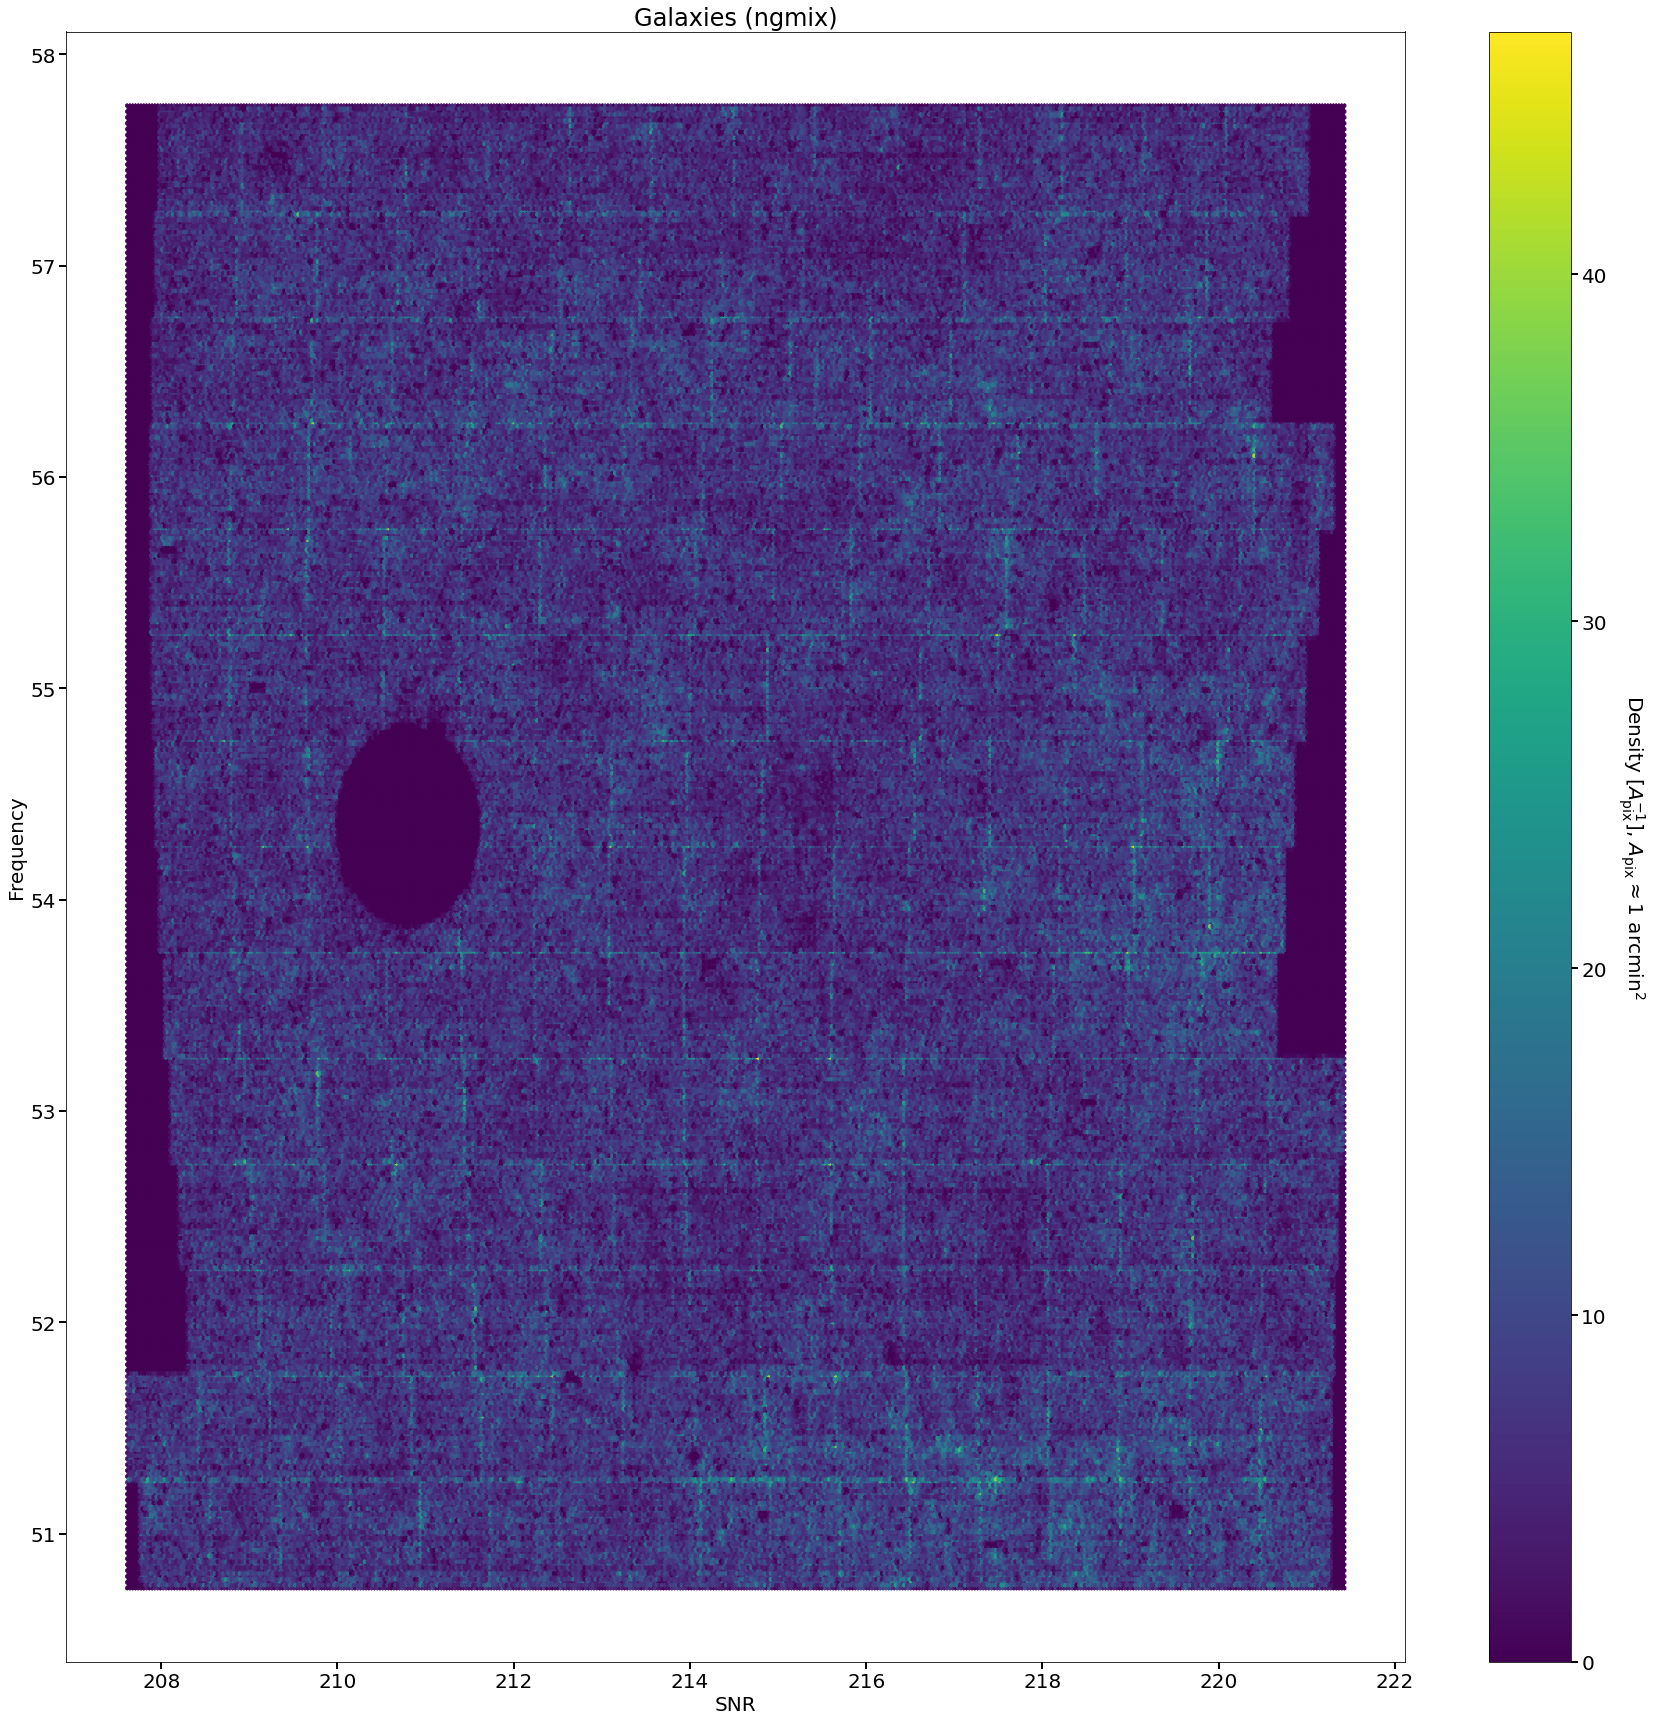

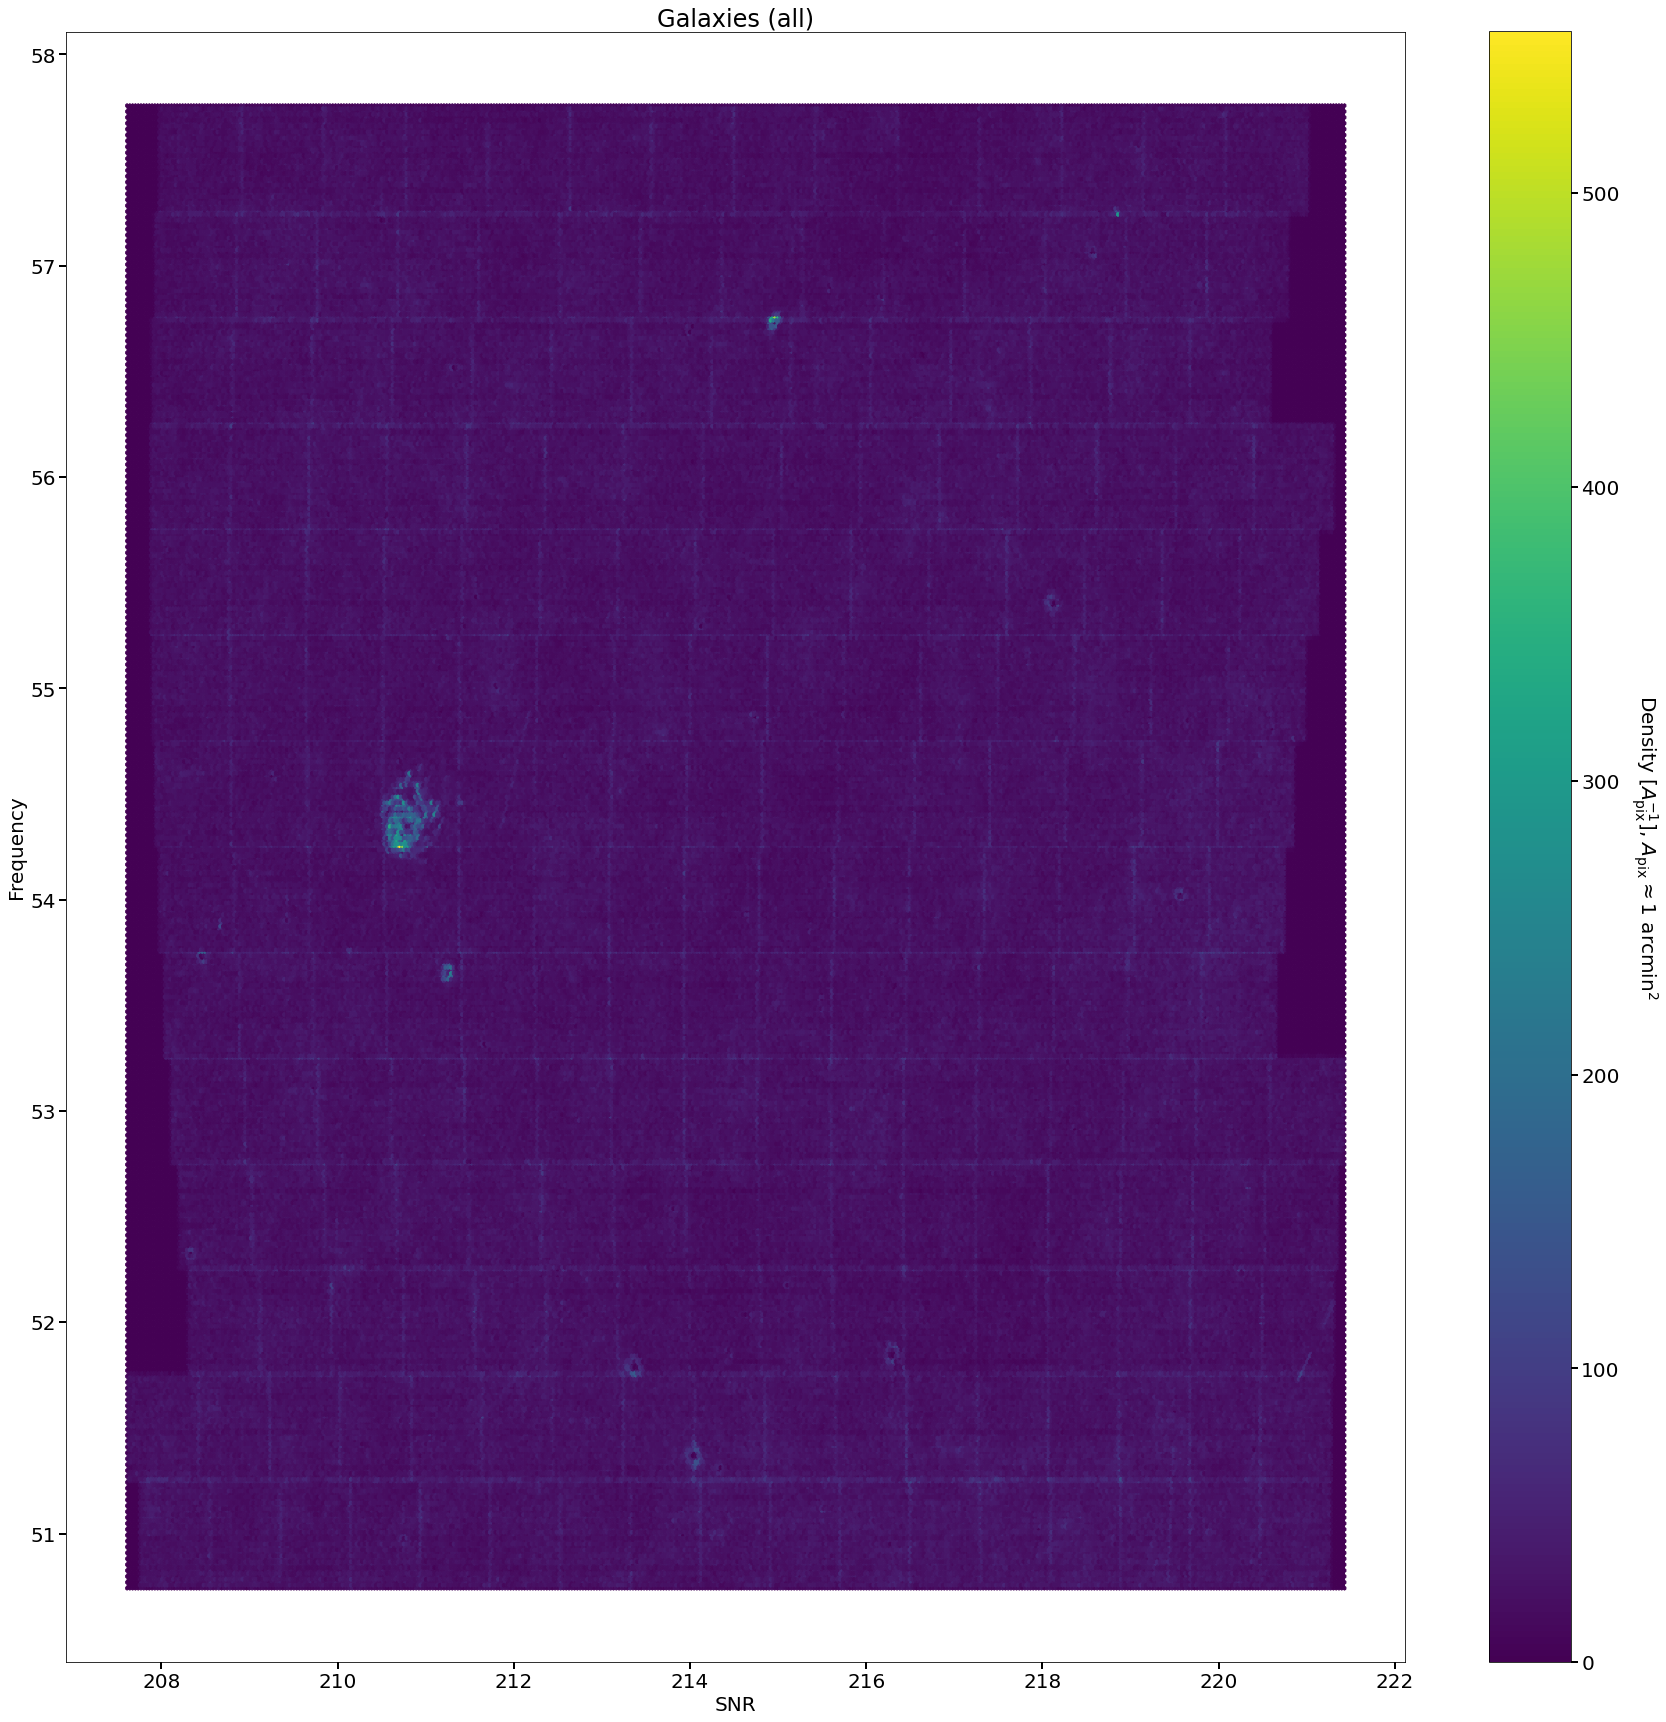

In [66]:
# Galaxies
Apix = 1 # [arcmin^2]
cbar_label = '{}, $A_{{\\rm pix}} \\approx {:.1g}$ arcmin$^2$'.format(cbar_label_base, Apix)
n_grid = int(np.sqrt(area_amin2) / Apix)
if verbose:
    print('Number of pixels = {}^2'.format(n_grid))
    
for sh in shapes_all:
    title = f'Galaxies ({sh})'
    out_path = f'{plot_dir}/galaxy_number_count_{sh}'
    plot_spatial_density(
        ra[sh],
        dec[sh],
        title,
        x_label,
        y_label,
        cbar_label,
        out_path,
        n_grid=n_grid,
        verbose=verbose
    )

#### Plot galaxy signal-to-noise distribution

ngmix


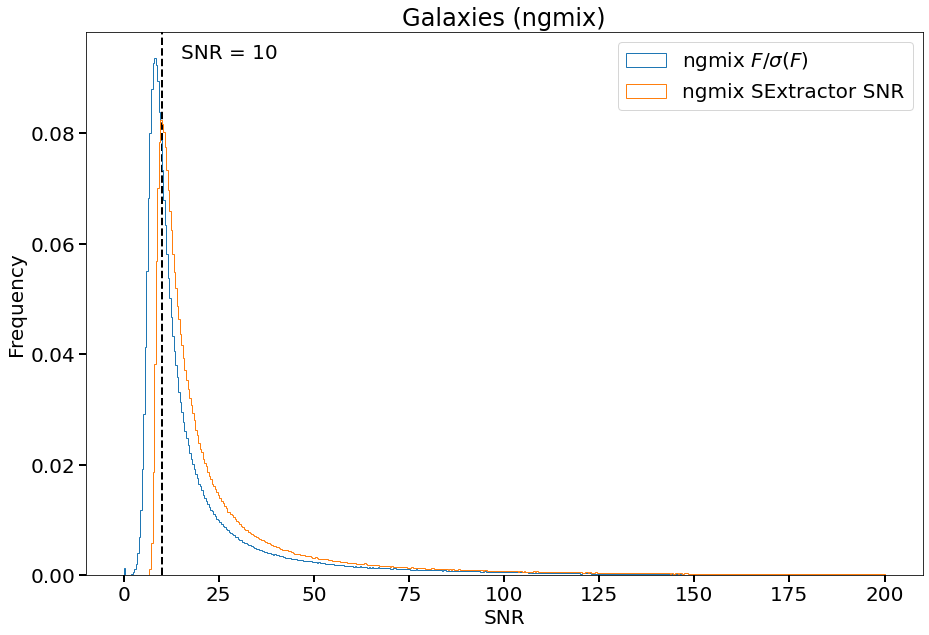

In [62]:
x_label = 'SNR'
y_label = 'Frequency'
density = True
x_range = (0, 200)
n_bin = 500
x_cut = 10

for sh in shapes:
    print_stats(sh, stats_file, verbose=verbose)

    labels = []
    if sh == 'ngmix':
    # Do not apply `mask_ns`, so use all galaxies
        xs = [
            dd['NGMIX_FLUX_NOSHEAR'][m_gal[sh]] / dd['NGMIX_FLUX_ERR_NOSHEAR'][m_gal[sh]],
            dd['SNR_WIN'][m_gal[sh]]
        ]
        labels.append([f'{sh} $F/\\sigma(F)$'])

    elif sh == 'galsim':
        xs = [
            dd['SNR_WIN'][m_gal[sh]]
        ]
  
    labels.append(f'{sh} SExtractor SNR')

    title = f'Galaxies ({sh})'

    out_name = f'hist_SNR_{sh}.pdf'
    out_path = os.path.join(plot_dir, out_name)

    plot_histograms(
        xs,
        labels,
        title,
        x_label,
        y_label,
        x_range,
        n_bin,
        out_path,
        vline_x=[x_cut],
        vline_lab=[f'SNR = {x_cut}']
    )

## Metacalibration for stars

### ngmix

In [71]:
star_metacal = {}
for sh in shapes:
    star_metacal[sh] = metacal(dd[ind_star], m_star[sh], masking_type='star')

#### Number density

In [78]:
# mask for 'no shear' images
mask_ns_stars = {}
n_star = {}

for sh in shapes:
    mask_ns_stars[sh] = star_metacal[sh].mask_dict['ns']
    n_star[sh] = len(star_metacal[sh].ns['g1'][mask_ns_stars[sh]])

    print_stats(f'{sh}:', stats_file, verbose=verbose)
    print_stats(f'Number of stars = {n_star[sh]}', stats_file, verbose=verbose)
    print_stats('Star density = {:.2f} stars/deg2'.format(n_star[sh] / area_deg2), stats_file, verbose=verbose)

ngmix:
Number of stars = 49517
Star density = 925.55 stars/deg2


## Additive bias

In [79]:
n_jack = 500

print_stats('additive bias', stats_file, verbose=verbose)

additive bias


In [80]:
c = {}
c_err = {}

for sh in shapes:
    print_stats(f'{sh}:', stats_file, verbose=verbose)

c[sh] = np.zeros(2)
c_err[sh] = np.zeros(2)
for comp in (0, 1):
    c[sh][comp], c_err[sh][comp] = jackknif_weighted_average(
        g_corr[sh][comp],
        w[sh],
        remove_size=0.05,
        n_realization=n_jack
    )
    c_dc = ufloat(c[sh][comp],c_err[sh][comp])
    print_stats(f'c_{comp+1} = {c_dc:.2eP}', stats_file, verbose=verbose)

ngmix:
c_1 = (-4.76±2.83)×10⁻⁴
c_2 = (4.88±2.96)×10⁻⁴


## Get quantities calibrated for both multiplicative and additive biase

In [82]:
g_corr_mc = {}

for sh in shapes:
    g_corr_mc[sh] = np.zeros_like(g_corr[sh])
    for comp in (0, 1):
        g_corr_mc[sh][comp] = g_corr[sh][comp] - c[sh][comp]

## Response matrix

### Mean

In [84]:
R_shear = {}

for sh in shapes:
    print_stats(f'{sh} galaxies:', stats_file, verbose=verbose)

    print_stats('total response matrix:', stats_file, verbose=verbose)
    rs = np.array2string(gal_metacal[sh].R)
    print_stats(rs, stats_file, verbose=verbose)

    print_stats('shear response matrix:', stats_file, verbose=verbose)
    R_shear[sh] = np.mean(gal_metacal[sh].R_shear, 2)
    rs = np.array2string(R_shear[sh])
    print_stats(rs, stats_file, verbose=verbose)

    print_stats('selection response matrix:', stats_file, verbose=verbose)
    rs = np.array2string(gal_metacal[sh].R_selection)
    print_stats(rs, stats_file, verbose=verbose)

ngmix galaxies:
total response matrix:
[[ 0.634 -0.00221]
 [ 2.58e-05  0.626]]
shear response matrix:
[[ 0.757 -0.00027]
 [ 0.000787  0.754]]
selection response matrix:
[[-0.123 -0.00194]
 [-0.000761 -0.128]]


In [85]:
R_shear_stars = {}

for sh in shapes:
    print_stats(f'{sh} stars:', stats_file, verbose=verbose)

    print_stats('total response matrix:', stats_file, verbose=verbose)
    rs = np.array2string(star_metacal[sh].R)
    print_stats(rs, stats_file, verbose=verbose)

    print_stats('shear response matrix:', stats_file, verbose=verbose)
    R_shear_stars[sh] = np.mean(star_metacal[sh].R_shear, 2)
    rs = np.array2string(R_shear_stars[sh])
    print_stats(rs, stats_file, verbose=verbose)

    print_stats('selection response matrix:', stats_file, verbose=verbose)
    rs = np.array2string(star_metacal[sh].R_selection)
    print_stats(rs, stats_file, verbose=verbose)

ngmix stars:
total response matrix:
[[ 0.391  0.00882]
 [-0.00608  0.407]]
shear response matrix:
[[ 0.39  0.00666]
 [-0.00628  0.404]]
selection response matrix:
[[ 0.000623  0.00216]
 [ 0.000199  0.00269]]


### Plot distribution of response matrix elements

In [86]:
x_label = 'response matrix element'
y_label = 'Frequency'
x_range = (-3, 3)
n_bin = 500

In [88]:
colors = ['blue', 'red','blue', 'red']
linestyles = ['-', '-', ':', ':']

ngmix:


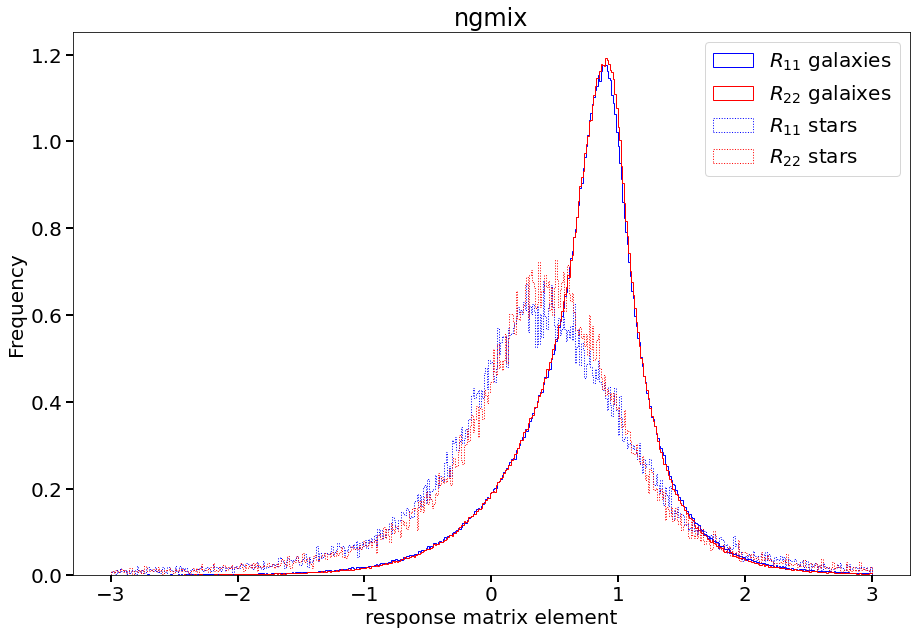

In [89]:
labels = [
    '$R_{11}$ galaxies',
    '$R_{22}$ galaixes',
    '$R_{11}$ stars',
    '$R_{22}$ stars'
]

for sh in shapes:
    
    print_stats(f'{sh}:', stats_file, verbose=verbose)

    xs = [
        gal_metacal[sh].R_shear[0,0],
        gal_metacal[sh].R_shear[1,1],
        star_metacal[sh].R_shear[0,0],
        star_metacal[sh].R_shear[1,1]
    ]
    title = sh
    
    out_name = f'R_{sh}_diag.pdf'
    out_path = os.path.join(plot_dir, out_name)
    
    plot_histograms(
        xs,
        labels,
        title,
        x_label,
        y_label,
        x_range,
        n_bin,
        out_path,
        colors=colors,
        linestyles=linestyles
    )

ngmix:


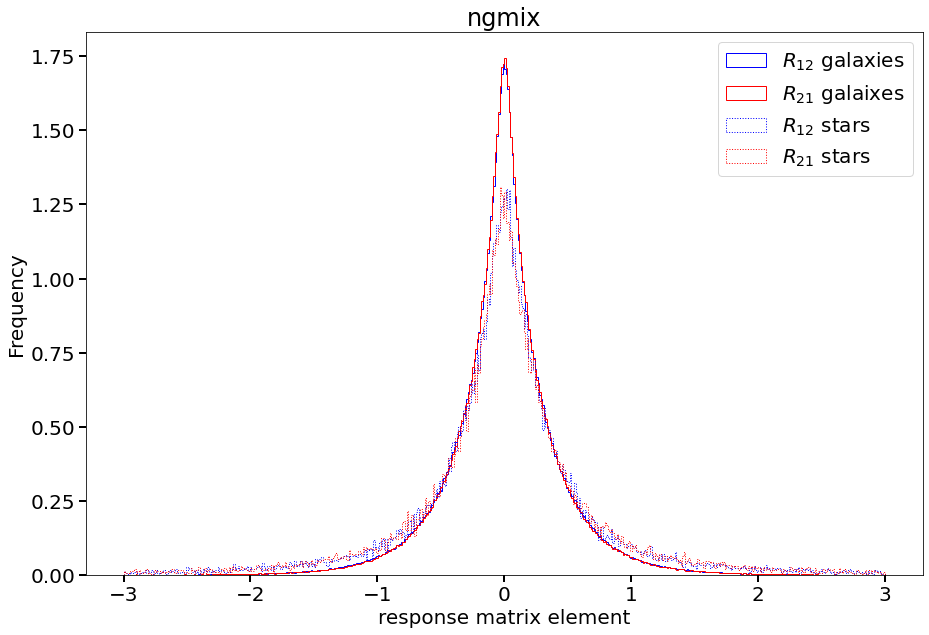

In [90]:
labels = [
    '$R_{12}$ galaxies',
    '$R_{21}$ galaixes',
    '$R_{12}$ stars',
    '$R_{21}$ stars'
]

for sh in shapes:
    print_stats(f'{sh}:', stats_file, verbose=verbose)

    xs = [gal_metacal[sh].R_shear[0,1],
          gal_metacal[sh].R_shear[1,0],
          star_metacal[sh].R_shear[0,1],
          star_metacal[sh].R_shear[1,0]
         ]
    title = sh
    out_name = f'R_{sh}_offdiag.pdf'
    out_path = os.path.join(plot_dir, out_name)

    plot_histograms(
        xs,
        labels,
        title,
        x_label,
        y_label,
        x_range, 
        n_bin,
        out_path,
        colors=colors,
        linestyles=linestyles
    )

## Ellipticities

In [ ]:
x_label = 'ellipticity'
y_label = 'Frequency'
x_range = (-1, 1)
n_bin = 500

labels = ['$e_1$', '$e_2$']
colors = ['blue', 'red']
linestyles = ['-', '-'] 

ngmix galaxies:


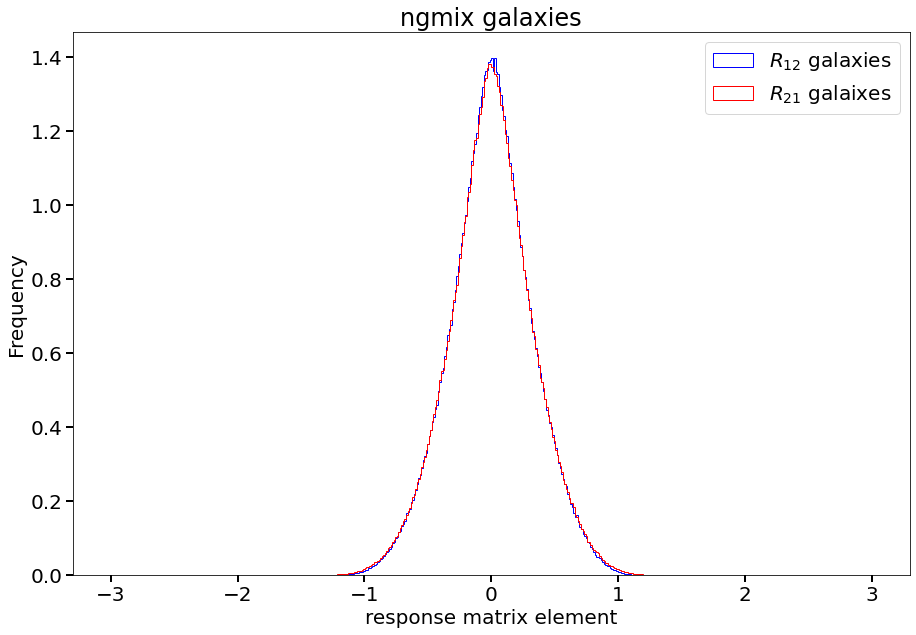

In [92]:
for sh in shapes:
    print_stats(f'{sh} galaxies:', stats_file, verbose=verbose)

    xs = [g_corr[sh][0], g_corr[sh][1]]
    weights = [w[sh]] * 2

    title = f'{sh} galaxies'
    out_name = f'ell_gal_{sh}.pdf'
    out_path = os.path.join(plot_dir, out_name)

    plot_histograms(
        xs, 
        labels, 
        title, 
        x_label, 
        y_label, 
        x_range, 
        n_bin,
        out_path,
        weights=weights, 
        colors=colors, 
        linestyles=linestyles
    )

ngmix stars:


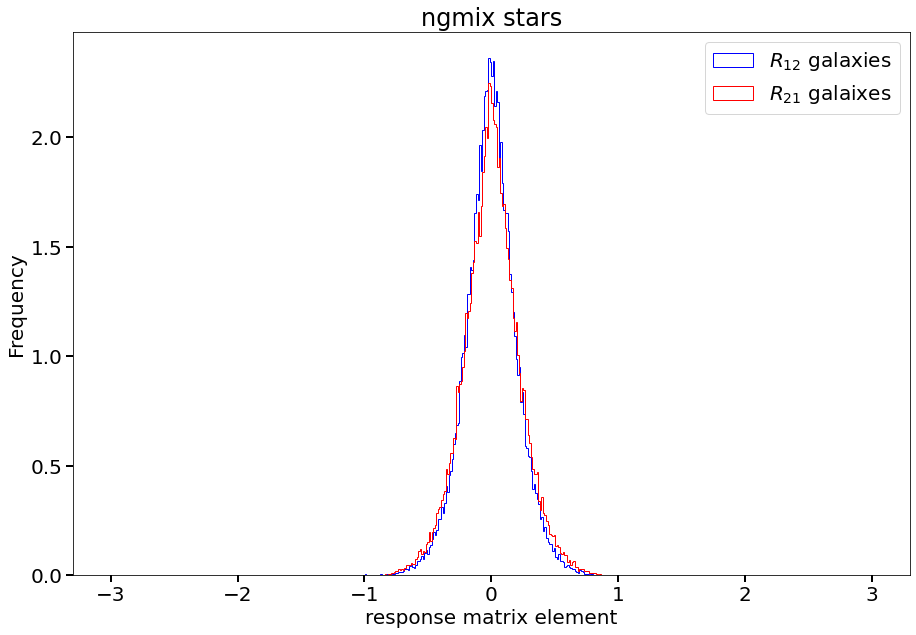

In [93]:
for sh in shapes:
    print_stats(f'{sh} stars:', stats_file, verbose=verbose)

    xs = [star_metacal[sh].ns['g1'][mask_ns_stars[sh]], star_metacal[sh].ns['g2'][mask_ns_stars[sh]]]
    weights = [star_metacal[sh].ns['w'][mask_ns_stars[sh]]] * 2

    title = f'{sh} stars'
    out_name = f'ell_stars_{sh}.pdf'
    out_path = os.path.join(plot_dir, out_name)

    plot_histograms(
        xs, 
        labels, 
        title, 
        x_label, 
        y_label, 
        x_range, 
        n_bin, 
        out_path,
        weights=weights, 
        colors=colors, 
        linestyles=linestyles
    )

In [120]:
# PSF keys for different shape measurement methods
key_PSF_ell = {}
key_PSF_size = {}
size_to_fwhm = {}

key_PSF_ell['ngmix'] = 'NGMIX_ELL_PSFo_NOSHEAR'
key_PSF_size['ngmix'] = 'NGMIX_T_PSFo_NOSHEAR'
size_to_fwhm['ngmix'] = T_to_fwhm

key_PSF_ell['galsim'] = 'GALSIM_PSF_ELL_ORIGINAL_PSF'
key_PSF_size['galsim'] = 'GALSIM_SIGMA_PSF_ORIGINAL_PSF'
size_to_fwhm['galsim'] = sigma_to_fwhm

In [96]:
x_range = (-0.15, 0.15)
n_bin = 250

ngmix PSF (uncorrected):


/home/mkilbing/.conda/envs/shapepipe/lib/python3.7/site-packages/numpy/lib/histograms.py:905: RuntimeWarning: invalid value encountered in true_divide
  return n/db/n.sum(), bin_edges


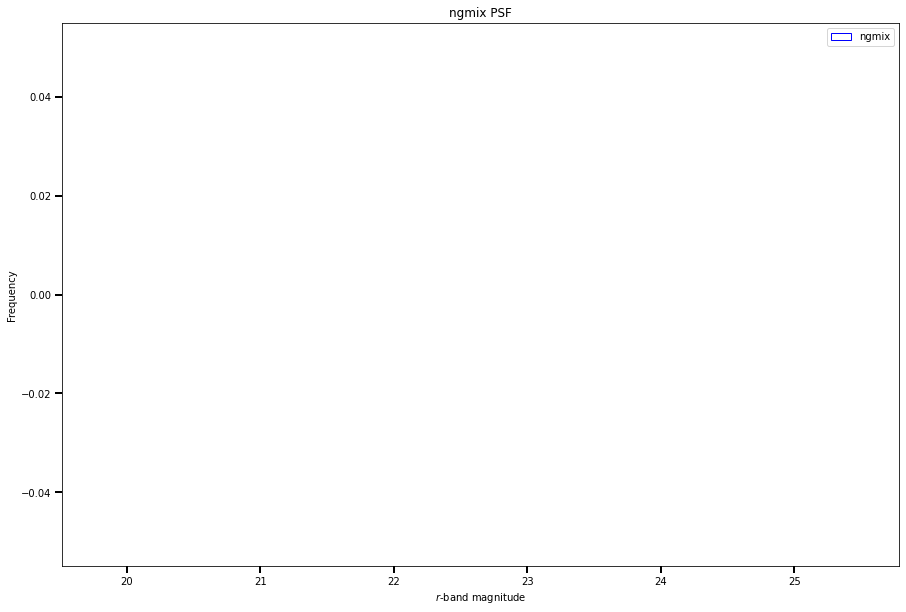

In [118]:
for sh in shapes:
    print_stats(f'{sh} PSF (uncorrected):', stats_file, verbose=verbose)

    key = key_PSF_ell[sh]

    xs = [
        dd[key][:,0][mask_ns_stars[sh]],
        dd[key][:,1][mask_ns_stars[sh]]
    ]

    title = f'{sh} PSF'
    out_name = f'ell_PSF_{sh}.pdf'
    out_path = os.path.join(plot_dir, out_name)

    plot_histograms(
        xs, 
        labels, 
        title, 
        x_label, 
        y_label, 
        x_range, 
        n_bin, 
        out_path,      
        colors=colors, 
        linestyles=linestyles
    )

## Magnitudes

In [110]:
x_label = '$r$-band magnitude'
y_label = 'Frequency'
x_range = (19.8, 25.5)
n_bin = 500

colors = ['blue', 'red']
linestyles = ['-', '-']

title = 'galaxies'
out_name = 'mag_gal.pdf'
out_path = os.path.join(plot_dir, out_name)

galaxies (ngmix):


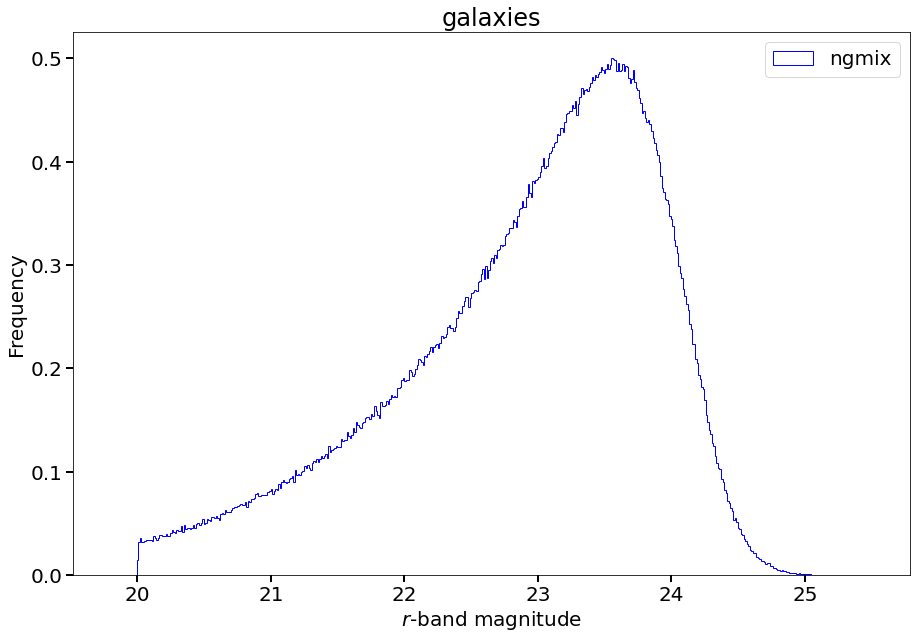

In [111]:
labels = []
xs = []

for sh in shapes:
    labels.append(sh)
    print_stats(f'galaxies ({sh}):', stats_file, verbose=verbose)

    xs.append(dd['MAG_AUTO'][m_gal[sh]][mask[sh]])

    plot_histograms(
        xs, 
        labels, 
        title, 
        x_label, 
        y_label, 
        x_range, 
        n_bin, 
        out_path,             
        colors=colors, 
        linestyles=linestyles
    )

## Ellipticity dispersion

In [112]:
for sh in shapes:
    print_stats(f'{sh}', stats_file, verbose=verbose)

    sig_eps = np.sqrt(np.var(g_corr[sh][0]) + np.var(g_corr[sh][1]))
    print_stats('Dispersion of complex ellipticity = {:.3f}' \
                ''.format(sig_eps), stats_file, verbose=verbose)
    print_stats('Dispersion of (average) single-component ellipticity = {:.3f} = {:.3f} / sqrt(2)' \
                ''.format(sig_eps /  np.sqrt(2), sig_eps), stats_file, verbose=verbose)

ngmix
Dispersion of complex ellipticity = 0.459
Dispersion of (average) single-component ellipticity = 0.324 = 0.459 / sqrt(2)
